In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

100%|██████████| 340k/340k [00:00<00:00, 378kB/s]

Extracting files...
Path to dataset files: C:\Users\saran\.cache\kagglehub\datasets\arjunbhasin2013\ccdata\versions\1


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("CC GENERAL.csv")
df.info()

customer_ids = df['CUST_ID']
df_features = df.drop('CUST_ID', axis=1)

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [11]:
df_features = df_features.fillna(df_features.median())

df_features['CREDIT_UTILIZATION'] = df_features['BALANCE'] / (df_features['CREDIT_LIMIT'] + 1e-6)

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df_features)

df_scaled = pd.DataFrame(df_scaled, columns=df_features.columns)

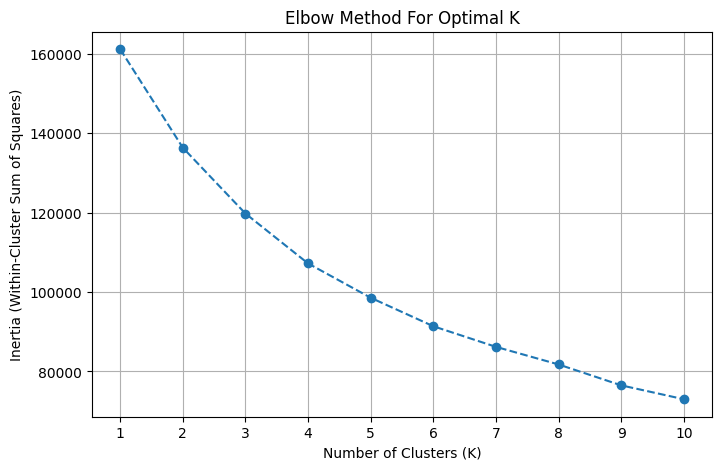

In [12]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    # random_state=42 ensures your results are reproducible
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [13]:
OPTIMAL_K = 5

final_model = KMeans(n_clusters=OPTIMAL_K, init='k-means++', random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(df_scaled)

df_final = df.copy()
df_final['CLUSTER'] = cluster_labels

cluster_profiles = df_final.drop('CUST_ID', axis=1).groupby('CLUSTER').mean()

print("Cluster Centroids (Averages per group):")
display(cluster_profiles)

Cluster Centroids (Averages per group):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CLUSTER,,,,,,,,,,,,,,,,,
0,1611.412188,0.974119,258.970253,199.714721,59.604505,835.343232,0.176038,0.091031,0.085466,0.167484,3.177822,3.228675,3169.099956,968.960071,873.535046,0.017452,11.504265
1,953.004349,0.967816,1463.984815,752.270000,711.913571,210.567380,0.905303,0.339865,0.724780,0.040502,0.766073,25.273711,4555.034206,1520.471390,610.334396,0.273012,11.647040
2,4151.939082,0.985629,9499.328000,6324.787308,3176.848385,701.292224,0.945390,0.746521,0.792558,0.073397,2.242308,103.119231,10485.000000,8945.866268,2530.392057,0.292039,11.957692
3,120.937923,0.421654,349.212088,209.055641,140.350687,322.260172,0.290602,0.077227,0.201621,0.039027,0.805628,4.384162,3693.444299,1075.250030,152.513271,0.230210,11.270288
4,4971.016859,0.968138,602.963261,376.615165,226.452695,5018.948617,0.326923,0.159033,0.215856,0.507278,15.606996,9.148148,8110.601384,3921.830037,2168.755119,0.038124,11.409465


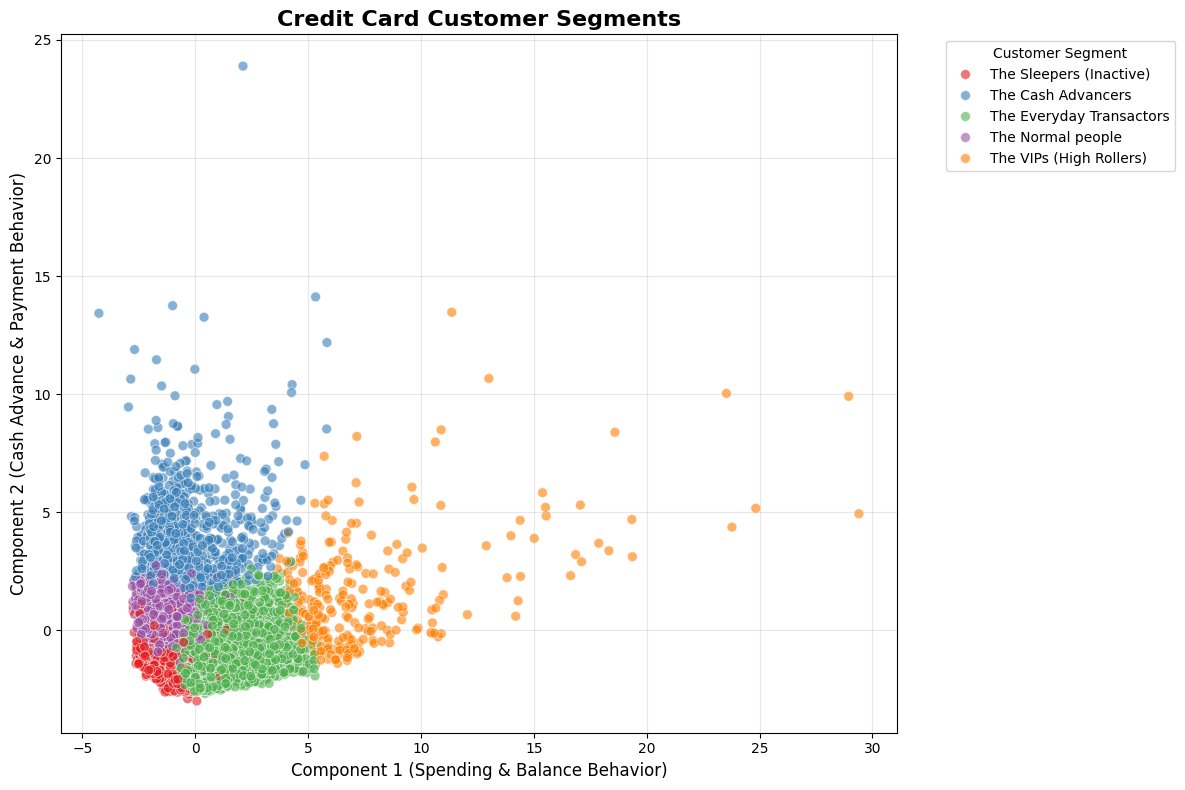

In [15]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['Component 1', 'Component 2'])

pca_df['Cluster'] = cluster_labels

persona_map = {
    0: 'The Normal people',
    1: 'The Everyday Transactors',
    2: 'The VIPs (High Rollers)',
    3: 'The Sleepers (Inactive)',
    4: 'The Cash Advancers'
}
pca_df['Persona'] = pca_df['Cluster'].map(persona_map)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='Component 1', 
    y='Component 2', 
    hue='Persona', 
    palette='Set1',  
    data=pca_df, 
    alpha=0.6,       
    s=50             
)

plt.title('Credit Card Customer Segments', fontsize=16, fontweight='bold')
plt.xlabel('Component 1 (Spending & Balance Behavior)', fontsize=12)
plt.ylabel('Component 2 (Cash Advance & Payment Behavior)', fontsize=12)
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()